In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes,add_disinfo_nodes ,spectral_grap
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n, k = 10000, 150
p_er = k / (n - 1)

In [3]:
TestGraf =  ws_opinion_graph(n,k,0.1,seed = 11)

MatrixGraf = create_matrix_rep(TestGraf)
mask = MatrixGraf.type == 'Human'


In [4]:
DeGrootops = MatrixGraf.opinions
DeGrootmat =MatrixGraf.matrix
DeGrootResult = DeGrootmat**100@DeGrootops

In [5]:
#spectral_grap(DeGrootmat,0.001)

In [6]:
Del_et_tidskridt  = 100
Del_to_tidskridt = 100
Del_tre_tidskridt = 100

In [7]:
MatrixGraf.opinions, no_media_no_disinfo_sim_results,no_media_no_disinfo_startcond,no_media_no_disinfo_endcond= simpel_simulering(MatrixGraf,Del_et_tidskridt)
average_opinionresult, average_distance_to_the_mean_result = data_processing(no_media_no_disinfo_sim_results,mask)


Simulating: 100%|██████████| 100/100 [00:07<00:00, 13.25it/s]


In [8]:
print(sum((MatrixGraf.opinions - DeGrootResult))/10000)

-0.010838467121936066


In [21]:
# plt.figure()
# plt.hist(no_media_no_disinfo_startcond[mask], bins=100, alpha=0.5, label='Startfordeling')
# plt.hist(no_media_no_disinfo_endcond[mask], bins=100, alpha=0.5, label='Simuleringsresultat')
# plt.xlim(-1, 1)
# plt.legend()
# plt.title('Holdningsfordeling uden medier og disinformation')
# plt.show()


In [10]:
MatrixGrafMedia=add_media_nodes(MatrixGraf,100,0.2,seed =11)
DeGrootopsmedia = MatrixGrafMedia.opinions

maskmedia = MatrixGrafMedia.type == 'Human'
MatrixGrafMedia.opinions, media_no_disinfo_sim_results,media_no_disinfo_startcond,media_no_disinfo_endcond= simpel_simulering(MatrixGrafMedia,Del_to_tidskridt)
media_average_opinionresult, media_average_distance_to_the_mean_result = data_processing(media_no_disinfo_sim_results,maskmedia)

DeGrootmatmedia =MatrixGrafMedia.matrix
DeGrootResultmedia = DeGrootmatmedia**100@DeGrootopsmedia
print(sum((MatrixGrafMedia.opinions - DeGrootResultmedia))/10000)

Simulating: 100%|██████████| 100/100 [00:05<00:00, 17.22it/s]


0.5061734221026347


In [11]:
print('Max = ',max(no_media_no_disinfo_endcond))
print('Min = ',min(no_media_no_disinfo_endcond))
print('|Diff| = ', abs(max(no_media_no_disinfo_endcond)-min(no_media_no_disinfo_endcond)))

Max =  -0.006824904246534786
Min =  -0.01673485276329108
|Diff| =  0.009909948516756296


In [12]:
#print(MatrixGrafMedia.opinions[MatrixGrafMedia.type == 'Media'])


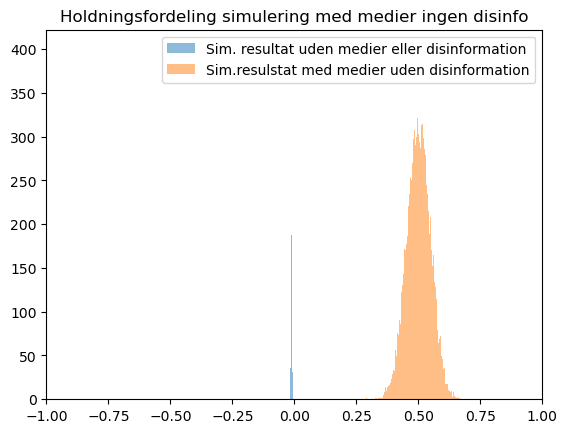

In [13]:
plt.figure()
plt.hist(media_no_disinfo_startcond[maskmedia], bins=100, alpha=0.5, label='Sim. resultat uden medier eller disinformation')
plt.hist(media_no_disinfo_endcond[maskmedia], bins=100, alpha=0.5, label='Sim.resulstat med medier uden disinformation')
plt.xlim(-1, 1)
plt.legend()
plt.title('Holdningsfordeling simulering med medier ingen disinfo')
plt.show()

In [14]:
MatrixGrafdisinfo=add_disinfo_nodes(MatrixGrafMedia,100,0.2,seed =11)
DeGrootopsmediadisinfo = MatrixGrafdisinfo.opinions

maskdisinfo = MatrixGrafdisinfo.type == 'Human'
MatrixGrafdisinfo.opinions, media_disinfo_sim_results,media_disinfo_startcond,media_disinfo_endcond= simpel_simulering(MatrixGrafdisinfo,Del_tre_tidskridt)
media_disinfo_average_opinionresult, media_disinfo_average_distance_to_the_mean_result = data_processing(media_disinfo_sim_results,maskdisinfo)

DeGrootmatmediadisinfo =MatrixGrafdisinfo.matrix
DeGrootResultmediadisinfo = DeGrootmatmediadisinfo**100@DeGrootmatmediadisinfo
print(sum((MatrixGrafMedia.opinions - DeGrootResultmedia))/10000)


Simulating: 100%|██████████| 100/100 [00:05<00:00, 17.98it/s]


0.5061734221026347


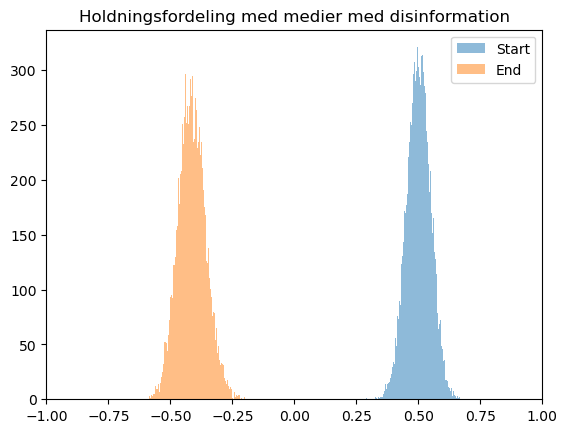

In [15]:
plt.figure()
plt.hist(media_disinfo_startcond[maskdisinfo], bins=100, alpha=0.5, label='Start')
plt.hist(media_disinfo_endcond[maskdisinfo], bins=100, alpha=0.5, label='End')
plt.xlim(-1, 1)
plt.legend()
plt.title('Holdningsfordeling med medier med disinformation')
plt.show()


In [16]:

totalgennemsnit = np.concatenate((average_opinionresult,media_average_opinionresult,media_disinfo_average_opinionresult))

totalgennemgennemsnit = np.concatenate((average_distance_to_the_mean_result,media_average_distance_to_the_mean_result,media_disinfo_average_distance_to_the_mean_result))


In [17]:
binsScenarie1 = np.histogram_bin_edges(np.concatenate([no_media_no_disinfo_startcond[mask], no_media_no_disinfo_endcond[mask],media_no_disinfo_endcond[maskmedia],media_disinfo_endcond[maskdisinfo]]), bins=100)


In [18]:
maskmedieend = MatrixGrafdisinfo.type == 'Media'

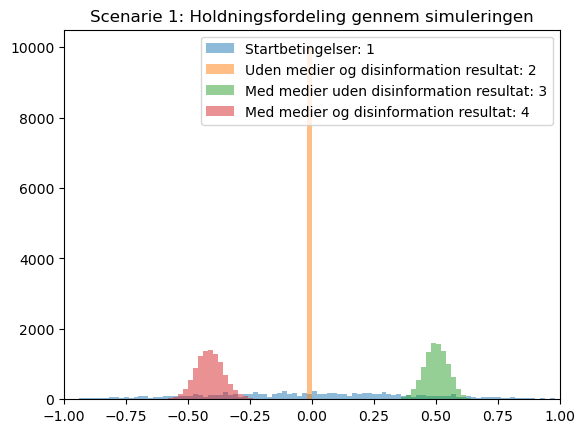

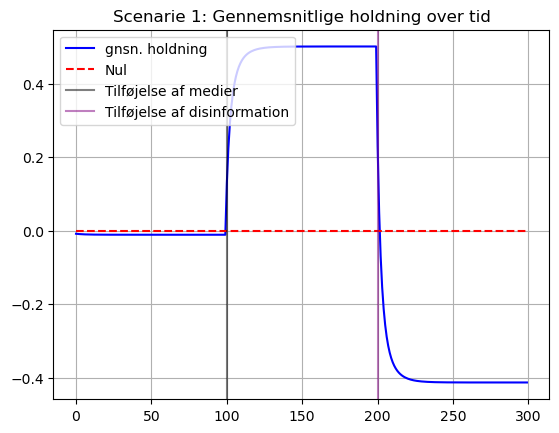

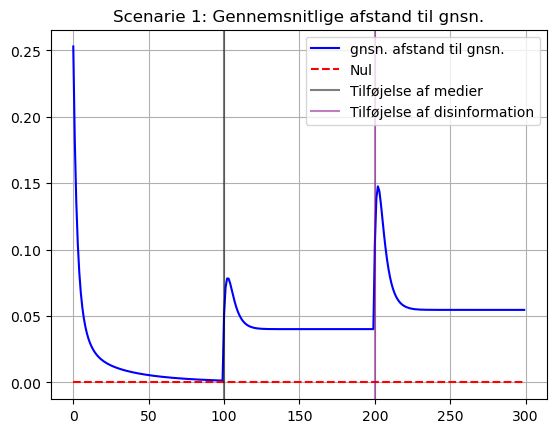

In [22]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond[mask], bins=binsScenarie1,alpha=0.5, label='Startbetingelser: 1')
plt.hist(no_media_no_disinfo_endcond[mask], bins=binsScenarie1, alpha=0.5, label='Uden medier og disinformation resultat: 2')
plt.hist(media_no_disinfo_endcond[maskmedia], bins=binsScenarie1, alpha=0.5, label='Med medier uden disinformation resultat: 3')
plt.hist(media_disinfo_endcond[maskdisinfo], bins=binsScenarie1, alpha=0.5, label='Med medier og disinformation resultat: 4')


plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 1: Holdningsfordeling gennem simuleringen')
plt.show()


plt.figure()
plt.plot(np.arange(len(totalgennemsnit)),totalgennemsnit,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(totalgennemsnit)),np.zeros(len(totalgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt,color = 'k', alpha=0.5, label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5, label = 'Tilføjelse af disinformation')

plt.legend(loc = 'upper left')
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige holdning over tid')
plt.show()

plt.figure()
plt.plot(np.arange(len(totalgennemgennemsnit)),totalgennemgennemsnit,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(totalgennemgennemsnit)),np.zeros(len(totalgennemgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt, color = 'k',alpha=0.5,label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5,label = 'Tilføjelse af disinformation')

plt.legend()
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige afstand til gnsn.')
plt.show()

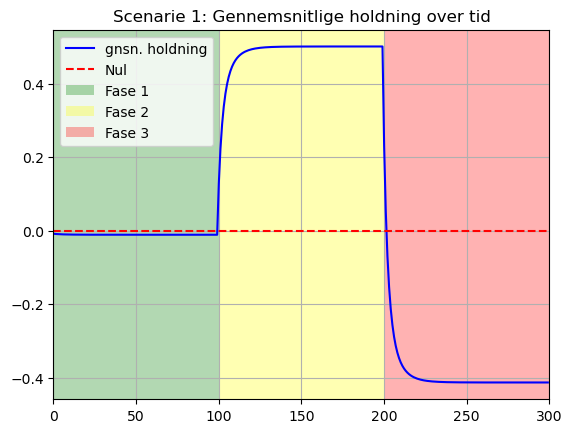

In [20]:
plt.figure()
plt.plot(np.arange(len(totalgennemsnit)), totalgennemsnit, 'b-', label='gnsn. holdning')
plt.plot(np.arange(len(totalgennemsnit)), np.zeros(len(totalgennemsnit)), 'r--', label='Nul')
total_len = len(totalgennemsnit)
plt.axvspan(0,                               Del_et_tidskridt,              facecolor='green',  alpha=0.3, label='Fase 1')
plt.axvspan(Del_et_tidskridt,                Del_et_tidskridt+Del_to_tidskridt, facecolor='yellow', alpha=0.3, label='Fase 2')
plt.axvspan(Del_et_tidskridt+Del_to_tidskridt, total_len,                    facecolor='red',    alpha=0.3, label='Fase 3')

plt.legend(loc='upper left')
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige holdning over tid')
plt.xlim(0,300)
plt.show()